# Расчёт волнового поля для произвольного списка слоёв

**Меняйте только `STRUCTURES` в ячейке «Настройки и структуры»**, затем выполните
**Restart Kernel → Run All**. Все функции уже включены в этот ноутбук; другие файлы не нужны.
Зависимости: `numpy`, `matplotlib`, `torch`.

Каждая структура — список пар **(название материала, толщина в Å)**, от падающей среды к подложке.
Первая и последняя среды полубесконечны и имеют условную толщину `0`.
Внутренние слои должны иметь положительные толщины. Для удаления слоя удалите его строку.

```python
STRUCTURES = [
    [('air', 0), ('Ni', 150), ('Si', 0)],
    [('air', 0), ('Ti', 80), ('Ni', 120), ('Si', 0)],
    [('air', 0), ('Si', 0)],  # без покрытия
]
```

Чтобы рассчитать только одну структуру, оставьте в `STRUCTURES` один вложенный список.
Добавляйте новые списки для сравнения нескольких структур. Для повторяющейся многослойки:

```python
STRUCTURES = [
    [('air', 0)] + [('Ni', 50), ('Ti', 50)] * 20 + [('Si', 0)]
]
```

`MATERIALS` — справочник SLD. Уже доступны `air`, `Ni`, `Ti`, `Cr`, `Si`.
Если нужен новый материал, добавьте один раз его `real` и положительную `absorption`
в единицах $10^{-6}$ Å$^{-2}$ (а `density` — для справки в г/см³).
Поле плотности само по себе не пересчитывает SLD: меняйте `real`/`absorption` согласованно.
Названия в `STRUCTURES` должны точно совпадать с ключами `MATERIALS`.

Подписи, границы, глубина карты и число графиков вычисляются по выбранным структурам.
Первая среда должна быть непоглощающей; подложка может быть любым материалом из справочника.


In [57]:
# -*- coding: utf-8 -*-
"""Нейтронные поля для структур на рис. 4 и 6, DOI: 10.1039/D5JA00237K.
Запуск: python neutron_fields_configurable.py
Зависимости: numpy, matplotlib, torch. Файлы исходного проекта не нужны.
Основные функции скопированы без изменения из new-wave-vibe.ipynb.
SLD: локальный расчёт periodictable 2.1.0 (версия калькулятора NIST),
https://www.ncnr.nist.gov/resources/activation/, 2026-10-01.
Падающая волна exp(+ikz); SLD = rho_real - i*rho_abs.
Границы резкие; воздух = вакуум; магнитная SLD не включена.
"""
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt



## Настройки и структуры — редактировать здесь

In [58]:
# Все значения SLD ниже в 10^-6 Å^-2, rho_abs >= 0.
# Получены neutron_sld(material, density=density, wavelength=2.4).
# Третий результат neutron_sld (incoherent SLD) НЕ является rho_abs.
# Формулы: rho_real = n*b_coh; rho_abs = n*sigma_abs/(2*lambda).
# Учитывается ядерная когерентная SLD и захват, без диффузных потерь.
MATERIALS = {
    'air': dict(density=0.0, real=0.0, absorption=0.0),
    'Ni': dict(density=8.902, real=9.407764749850172, absorption=0.0011404490352502582),
    'Ti': dict(density=4.540, real=-1.9248657571990726, absorption=0.0009673155188374778),
    'Cr': dict(density=7.190, real=3.027007086187118, absorption=0.0007062999552361183),
    'Si': dict(density=2.330, real=2.0737423003838087, absorption=0.000023757942260997373),
}

# Редактируемые параметры. k_perp НЕ равен Q: Q = 2*k_perp.
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
WAVELENGTH_A = 4.52  # только для пересчёта k_perp <-> угол
K_MIN, K_MAX, N_K = 0.0002, 0.03, 1200  # Å^-1
DZ_A = 0.5
ABSORPTION = True
OUTPUT_DIR = Path('neutron_field_results')
AIR_EXTENT_A = 300.0       # область перед поверхностью для графика
SUBSTRATE_EXTENT_A = 100.0 # отображаемая глубина в подложке
CHECK_WITH_DIRECT_SOLVER = False  # дополнительная СЛАУ для небольших структур

# ================================================================
# СТРУКТУРЫ МЕНЯЮТСЯ ТОЛЬКО ЗДЕСЬ.
# Каждая строка: (материал, толщина в Å), от падающей среды к подложке.
# Первая и последняя среды полубесконечны: их толщина обязательно 0.
# Добавляйте/удаляйте/переставляйте внутренние строки и целые структуры.
# Допустима структура без плёнок: [('air', 0), ('Si', 0)].
# Повторы, например: [('air', 0)] + [('Ni', 50), ('Ti', 50)] * 20 + [('Si', 0)].
# Новый материал добавляется один раз в справочник MATERIALS выше.
# ================================================================
stdr = [('air', 0)]
for i in range(90):
    stdr.append(('Ni', 50))
    stdr.append(('Ti', 50))
stdr.append(('Si', 0))    
print(len(stdr))
STRUCTURES = [
   
    [
        ('air', 0),
        ('Ni', 100),
        ('Ti', 700),
        ('Ni', 500),
        ('Si', 0),
    ],
]



print(torch.cuda.is_available() )


182
False


## Расчётное ядро

In [59]:
def sqrt_decay_branch(z: torch.Tensor) -> torch.Tensor:
    """
    Комплексный sqrt с выбором ветви, обеспечивающей затухание:
        Im(k) >= 0.
    Если k чисто вещественное, выбирается Re(k) >= 0.
    """
    z = torch.as_tensor(z, dtype=torch.complex128, device=z.device)

    k = torch.sqrt(z)

    # Основная проверка: затухающая ветвь
    k = torch.where(k.imag < 0.0, -k, k)

    # Не переворачиваем почти вещественный корень: это может нарушить Im(k) >= 0.
    k = torch.where((k.imag == 0) & (k.real < 0), -k, k)

    return k

def safe_div(num: torch.Tensor, den: torch.Tensor, eps: float = 1e-30) -> torch.Tensor:
    """
    Безопасное комплексное деление.
    Заменяет слишком малые знаменатели на eps.
    """
    num = torch.as_tensor(num, dtype=torch.complex128, device=den.device)
    den = torch.as_tensor(den, dtype=torch.complex128, device=den.device)

    small = torch.abs(den) < eps

    if torch.any(small):
        den = torch.where(
            small,
            torch.full_like(den, eps, dtype=torch.complex128),
            den
        )

    return num / den

def stable_multilayer_fields(
    q,
    layers,
    np_pi=np.pi,
    device=None,
    eps=1e-30
):
    """
    Устойчивый расчёт многослойной структуры методом scattering-рекурсии.

    Параметры
    ---------
    q : torch.Tensor или array-like
        Нормальная компонента k_perp падающей волны, Å^-1 (НЕ Q = 2*k_perp).
        Форма: (nq,)

    layers : torch.Tensor или array-like
        Массив слоёв формы (n_media, 3):
            columns: thickness [Å], Re(SLD), magnitude of absorptive SLD
            SLD задана в единицах 10^-6 Å^-2; комплексная SLD = Re - i*abs(Im).

        Ожидается:
            layers[0]      падающая среда
            layers[1:-1]   конечные слои
            layers[-1]     подложка

    np_pi : float or torch.Tensor
        Число pi; множитель 4 уже присутствует в формуле для k.

    device : str or torch.device, optional
        Устройство.

    eps : float
        Регуляризация для деления.

    Возвращает
    ----------
    r_global : Tensor, shape (nq,)
        Полная амплитуда отражения.

    k : Tensor, shape (nq, n_media)
        Волновые числа с ветвью Im(k) >= 0.

    A_left : Tensor, shape (nq, n_media)
        Амплитуда прямой волны на левой границе каждой среды.

    B_right : Tensor, shape (nq, n_media)
        Амплитуда обратной волны на правой границе каждой конечной среды.
        Для подложки B_right = 0.
        Для падающей среды сюда записана r_global для удобства.

    p : Tensor, shape (nq, n_media)
        Факторы прохождения p_j = exp(i k_j d_j).
        Для падающей среды и подложки p = 1.

    R_eff : Tensor, shape (nq, n_media)
        Эффективные отражения для конечных слоёв.
        Нужно в основном для диагностики.
    """

    if device is None:
        device = q.device if torch.is_tensor(q) else torch.device("cpu")
    else:
        device = torch.device(device)

    q = torch.as_tensor(q, dtype=torch.complex128, device=device).reshape(-1)
    layers = torch.as_tensor(layers, dtype=torch.float64, device=device)

    if layers.ndim != 2 or layers.shape[1] != 3:
        raise ValueError("layers: ожидаются столбцы [толщина, Re SLD, поглощение].")
    if not torch.all(torch.isfinite(layers)) or not torch.all(torch.isfinite(q)):
        raise ValueError("Входные данные содержат NaN или inf.")
    if torch.any(q.imag != 0) or torch.any(q.real <= 0):
        raise ValueError("k_perp должен быть действительным и положительным.")
    if layers[0, 2] != 0:
        raise ValueError("В этой модели падающая среда должна быть непоглощающей.")
    if torch.any(layers[1:-1, 0] <= 0):
        raise ValueError("Толщины конечных слоёв должны быть положительными.")
    n_media = layers.shape[0]

    if n_media < 2:
        raise ValueError("layers должен содержать хотя бы падающую среду и подложку.")

    n_fin = n_media - 2
    nq = q.shape[0]

    # ------------------------------------------------------------------
    # 1. Пассивная среда при прямой волне exp(+i*k*z):
    #    sld[0] = 0
    #    sld[1:] = (Re_layers - Re_incident) - i |Im_layers|, умноженное на 1e-6
    # ------------------------------------------------------------------
    sld = torch.zeros(n_media, dtype=torch.complex128, device=device)

    if n_media > 1:
        sld[1:] = (
            (layers[1:, 1] - layers[0, 1])
            - 1j * torch.abs(layers[1:, 2])
        ) * 1.0e-6

    # ------------------------------------------------------------------
    # 2. Волновые числа с правильной ветвью затухания
    # ------------------------------------------------------------------
    const = torch.as_tensor(np_pi, dtype=torch.float64, device=device)

    arg = q[:, None] ** 2.0 - 4.0 * const * sld[None, :]

    k = sqrt_decay_branch(arg)

    # ------------------------------------------------------------------
    # 3. Интерфейсные коэффициенты
    #    r_if[:, j]  : отражение на границе j -> j+1 при падении слева
    #    r_back[:, j]: отражение при падении справа
    #    t_if[:, j]  : прохождение слева направо
    #    t_back[:, j]: прохождение справа налево
    # ------------------------------------------------------------------
    k_left = k[:, :-1]
    k_right = k[:, 1:]

    den_if = k_left + k_right

    r_if = safe_div(k_left - k_right, den_if, eps=eps)
    r_back = -r_if

    t_if = safe_div(2.0 * k_left, den_if, eps=eps)
    t_back = safe_div(2.0 * k_right, den_if, eps=eps)

    # ------------------------------------------------------------------
    # 4. Факторы прохождения через слои
    #    p_j = exp(i k_j d_j)
    #
    #    При Im(k_j) >= 0 выполняется |p_j| <= 1.
    #    Это исключает растущие множители; пассивность проверяется также по потоку.
    # ------------------------------------------------------------------
    p = torch.ones_like(k)

    if n_fin > 0:
        d = layers[1:n_media - 1, 0].to(dtype=torch.float64, device=device)
        p[:, 1:n_media - 1] = torch.exp(
            1j * k[:, 1:n_media - 1] * d[None, :]
        )

    # ------------------------------------------------------------------
    # 5. Обратный проход: эффективные отражения R_j
    #
    #    R_j определяется на правой границе слоя j и включает все слои правее.
    #    Для последнего конечного слоя:
    #        R_last = r_last, interface last -> substrate
    # ------------------------------------------------------------------
    R_eff = torch.zeros(nq, n_media, dtype=torch.complex128, device=device)

    A_left = torch.zeros(nq, n_media, dtype=torch.complex128, device=device)
    B_right = torch.zeros(nq, n_media, dtype=torch.complex128, device=device)

    # Случай без конечных слоёв: только граница среда -> подложка
    if n_fin == 0:
        r_global = r_if[:, 0].clone()

        A_left[:, 0] = 1.0
        B_right[:, 0] = r_global

        A_left[:, 1] = t_if[:, 0]
        B_right[:, 1] = 0.0

        return r_global, k, A_left, B_right, p, R_eff

    last_fin = n_fin  # индекс последнего конечного слоя, равный n_media - 2

    # Граница последний конечный слой -> подложка
    R_eff[:, last_fin] = r_if[:, last_fin]

    # Движемся справа налево по конечным слоям
    for j in range(last_fin - 1, 0, -1):
        # Эффективное отражение следующего слоя, приведённое к левой границе слоя j+1
        rho_next = p[:, j + 1] ** 2 * R_eff[:, j + 1]

        den_s = 1.0 - r_back[:, j] * rho_next

        R_eff[:, j] = (
            r_if[:, j]
            + safe_div(t_if[:, j] * t_back[:, j] * rho_next, den_s, eps=eps)
        )

    # ------------------------------------------------------------------
    # 6. Полное отражение от всей структуры
    # ------------------------------------------------------------------
    rho_1 = p[:, 1] ** 2 * R_eff[:, 1]

    den_0 = 1.0 - r_back[:, 0] * rho_1

    r_global = (
        r_if[:, 0]
        + safe_div(t_if[:, 0] * t_back[:, 0] * rho_1, den_0, eps=eps)
    )

    # ------------------------------------------------------------------
    # 7. Прямой проход: амплитуды внутри слоёв
    #
    #    A_left[j]  : амплитуда прямой волны на левой границе слоя j
    #    B_right[j] : амплитуда обратной волны на правой границе слоя j
    # ------------------------------------------------------------------
    A_left[:, 0] = 1.0
    B_right[:, 0] = r_global  # удобно для расчёта поля в падающей среде

    A_left[:, 1] = safe_div(t_if[:, 0], den_0, eps=eps)
    B_right[:, 1] = p[:, 1] * R_eff[:, 1] * A_left[:, 1]

    for j in range(1, last_fin):
        # Прямая волна на правой границе слоя j
        F_j = A_left[:, j] * p[:, j]

        # Нагрузка со стороны слоя j+1, приведённая к интерфейсу j
        rho_next = p[:, j + 1] ** 2 * R_eff[:, j + 1]

        den = 1.0 - r_back[:, j] * rho_next

        A_left[:, j + 1] = safe_div(t_if[:, j] * F_j, den, eps=eps)

        B_right[:, j + 1] = p[:, j + 1] * R_eff[:, j + 1] * A_left[:, j + 1]

    # Подложка: только прямая волна, обратной волны нет
    F_last = A_left[:, last_fin] * p[:, last_fin]

    A_left[:, n_media - 1] = t_if[:, last_fin] * F_last
    B_right[:, n_media - 1] = 0.0

    return r_global, k, A_left, B_right, p, R_eff

def evaluate_psi_squared_stable(
    A_left,
    B_right,
    k,
    layers,
    z,
    z0=0.0,
    eps=1e-30
):
    """
    Устойчивый расчёт |psi(z)|^2 для многослойной структуры.

    Параметры
    ---------
    A_left : Tensor, shape (nq, n_media)
        Амплитуды прямых волн на левых границах сред.

    B_right : Tensor, shape (nq, n_media)
        Амплитуды обратных волн на правых границах сред.
        B_right[:, 0] должен содержать r_global.

    k : Tensor, shape (nq, n_media)
        Волновые числа.

    layers : Tensor, shape (n_media, 3)
        Массив слоёв: thickness, Re(SLD), Im(SLD).

    z : Tensor or array-like, shape (nz,)
        Точки, в которых вычисляется волновая функция.

    z0 : float or Tensor
        Координата передней поверхности.
        По умолчанию 0.

    eps : float
        Не используется напрямую, оставлено для совместимости стиля.

    Возвращает
    ----------
    psi_squared : Tensor, shape (nq, nz)
        |psi(q_i, z_j)|^2.
    """

    device = A_left.device

    z = torch.as_tensor(z, dtype=torch.float64, device=device).reshape(-1)
    layers = torch.as_tensor(layers, dtype=torch.float64, device=device)

    nq, n_media = A_left.shape
    nz = z.shape[0]

    psi_squared = torch.zeros(nq, nz, dtype=torch.float64, device=device)
    filled = torch.zeros(nz, dtype=torch.bool, device=device)

    n_fin = n_media - 2

    z0 = torch.as_tensor(z0, dtype=torch.float64, device=device).reshape(())

    # ------------------------------------------------------------------
    # Границы конечных слоёв:
    #
    # bounds[0] = z0
    # bounds[1] = z0 + d_1
    # bounds[2] = z0 + d_1 + d_2
    # ...
    # bounds[n_fin] = конец последнего конечного слоя
    # ------------------------------------------------------------------
    if n_fin > 0:
        d = layers[1:n_media - 1, 0].to(dtype=torch.float64, device=device)

        bounds = torch.empty(n_fin + 1, dtype=torch.float64, device=device)
        bounds[0] = z0
        bounds[1:] = z0 + torch.cumsum(d, dim=0)

        z_end = bounds[-1]
    else:
        bounds = torch.tensor([z0, z0], dtype=torch.float64, device=device)
        z_end = z0

    # ------------------------------------------------------------------
    # Падающая среда: z < z0
    #
    # psi_0(z) = exp(i k_0 (z - z0)) + r_global exp(-i k_0 (z - z0))
    # ------------------------------------------------------------------
    mask_incident = (z < bounds[0]) & (~filled)

    if torch.any(mask_incident):
        zz = z[mask_incident]
        x = zz - bounds[0]

        k0 = k[:, 0].unsqueeze(1)
        r0 = B_right[:, 0].unsqueeze(1)

        psi = (
            torch.exp(1j * k0 * x[None, :])
            + r0 * torch.exp(-1j * k0 * x[None, :])
        )

        psi_squared[:, mask_incident] = torch.abs(psi) ** 2
        filled[mask_incident] = True

    # ------------------------------------------------------------------
    # Конечные слои: j = 1 ... n_media - 2
    #
    # psi_j(z) =
    #   A_left[j]  exp(i k_j (z - z_left))
    # + B_right[j] exp(i k_j (z_right - z))
    # ------------------------------------------------------------------
    for j in range(1, n_media - 1):
        z_left = bounds[j - 1]
        z_right = bounds[j]

        # Чтобы не дублировать границы, последний конечный слой берём включительно
        if j == n_media - 2:
            mask = (z >= z_left) & (z <= z_right) & (~filled)
        else:
            mask = (z >= z_left) & (z < z_right) & (~filled)

        if not torch.any(mask):
            continue

        zz = z[mask]

        x = zz - z_left
        d_layer = z_right - z_left

        A = A_left[:, j].unsqueeze(1)
        B = B_right[:, j].unsqueeze(1)
        kj = k[:, j].unsqueeze(1)

        psi = (
            A * torch.exp(1j * kj * x[None, :])
            + B * torch.exp(1j * kj * (d_layer - x)[None, :])
        )

        psi_squared[:, mask] = torch.abs(psi) ** 2
        filled[mask] = True

    # ------------------------------------------------------------------
    # Подложка: z > z_end
    #
    # psi_sub(z) = A_left[-1] exp(i k_sub (z - z_end))
    # Обратной волны в подложке нет.
    # ------------------------------------------------------------------
    mask_substrate = (z >= z_end) & (~filled)

    if torch.any(mask_substrate):
        zz = z[mask_substrate]
        x = zz - z_end

        A_sub = A_left[:, -1].unsqueeze(1)
        k_sub = k[:, -1].unsqueeze(1)

        psi = A_sub * torch.exp(1j * k_sub * x[None, :])

        psi_squared[:, mask_substrate] = torch.abs(psi) ** 2
        filled[mask_substrate] = True

    if not torch.all(filled):
        raise ValueError("Не все координаты z попали в области модели; проверьте z и границы.")

    return psi_squared

def integrate_layers_analytic(A_left, B_right, k, layers):
    """Точные интегралы |psi|² по конечным слоям, Tensor (n_layers, n_k), Å.

    A_left и B_right отсчитываются от разных границ слоя.
    Для каждого слоя psi(x)=A*exp(ikx)+B*exp(ik(d-x)).
    Координатная сетка и psi2_test не требуются.
    """
    layers = torch.as_tensor(layers, dtype=torch.float64, device=k.device)
    if A_left.shape != k.shape or B_right.shape != k.shape:
        raise ValueError("A_left, B_right и k должны иметь одинаковую форму (n_k, n_media).")
    if layers.shape != (k.shape[1], 3):
        raise ValueError("layers должен иметь форму (n_media, 3).")
    kj = k[:, 1:-1]
    d = layers[None, 1:-1, 0]
    A, B = A_left[:, 1:-1], B_right[:, 1:-1]
    beta = kj.imag
    # При beta=0 первый множитель равен d; деления 0/0 нет.
    den = torch.where(beta != 0, 2 * beta, torch.ones_like(beta))
    attenuation_integral = torch.where(beta != 0, -torch.expm1(-2 * beta * d) / den, d)
    integral_psi2 = (
        (torch.abs(A)**2 + torch.abs(B)**2) * attenuation_integral
        + 2 * (A * B.conj()).real * torch.exp(-beta * d)
        * d * torch.sinc(kj.real * d / torch.pi)
    )
    return integral_psi2.transpose(0, 1)

def flux_balance_diagnostics(q, r, k, A_left, B_right, p, layers, label=""):
    """R, T, потери через токи и независимый интеграл |psi|².

    Токи нормированы на падающий ток; потери учитываются в конечных слоях.
    T — поток на входе в подложку. Никакого обрезания R/T/L к [0, 1] нет.
    """
    k_inc = k[:, 0].real
    R = torch.abs(r) ** 2
    T = k[:, -1].real / k_inc * torch.abs(A_left[:, -1]) ** 2

    # Значения psi и dpsi/dz на левой и правой границах каждой среды.
    psi_left = A_left + B_right * p
    dpsi_left = 1j * k * (A_left - B_right * p)
    psi_right = A_left * p + B_right
    dpsi_right = 1j * k * (A_left * p - B_right)
    J_left = (psi_left.conj() * dpsi_left).imag / k_inc[:, None]
    J_right = (psi_right.conj() * dpsi_right).imag / k_inc[:, None]
    L_layers = J_left[:, 1:-1] - J_right[:, 1:-1]
    L_current = L_layers.sum(dim=1)

    # Точный интеграл общий с расчётом послойного поглощения ниже.
    integral_psi2 = integrate_layers_analytic(A_left, B_right, k, layers).transpose(0, 1)
    L_integral_layers = 4 * torch.pi * layers[None, 1:-1, 2].abs() * 1e-6 * integral_psi2 / k_inc[:, None]
    L_integral = L_integral_layers.sum(dim=1)
    residual = R + T + L_integral - 1
    idx = int(torch.argmax(residual.abs()).item())
    errors = {
        "R+T+L_integral-1": residual.abs().max().item(),
        "R+T+L_current-1": (R + T + L_current - 1).abs().max().item(),
        "L_current-L_integral": (L_current - L_integral).abs().max().item(),
        "L_layer_current-L_layer_integral": (L_layers - L_integral_layers).abs().max().item() if L_layers.numel() else 0.0,
        "jump_psi": (psi_right[:, :-1] - psi_left[:, 1:]).abs().max().item(),
        "jump_dpsi": (dpsi_right[:, :-1] - dpsi_left[:, 1:]).abs().max().item(),
        "jump_normalized_current": (J_right[:, :-1] - J_left[:, 1:]).abs().max().item(),
    }
    print(f"\n{label}")
    print(f"max R = {R.max().item():.10g}; max T = {T.max().item():.10g}")
    print(f"R+T: {(R+T).min().item():.10g} ... {(R+T).max().item():.10g}")
    print(f"L: {L_integral.min().item():.10g} ... {L_integral.max().item():.10g}")
    for name, value in errors.items():
        print(f"max |{name}| = {value:.3e}")
    print(f"Худшая точка полного баланса: k_perp = {q[idx].item():.10g} Å^-1")
    if R.max() > 1 + 1e-8 or T.max() > 1 + 1e-8 or L_integral.min() < -1e-8:
        raise RuntimeError("Нарушена пассивность: проверьте знаки SLD и потоков.")
    if not torch.all(torch.isfinite(residual)) or errors["R+T+L_integral-1"] > 1e-8:
        raise RuntimeError("Полный баланс потоков не прошёл проверку.")
    return dict(R=R, T=T, L=L_integral, L_current=L_current,
                L_layers=L_layers, residual=residual, errors=errors)



## Построение структур, графики и сохранение

In [60]:
def make_layers(stack, absorption=True, device='cpu'):
    """Полный список сред [(material, thickness_A), ...] -> names, layers."""
    if len(stack) < 2:
        raise ValueError('Нужны падающая среда и подложка, даже если плёнок нет.')
    rows, names = [], []
    for j, entry in enumerate(stack):
        if not isinstance(entry, (list, tuple)) or len(entry) != 2:
            raise ValueError(f'Строка {j+1}: нужен формат (материал, толщина).')
        name, thickness = entry
        if name not in MATERIALS:
            raise ValueError(f'Неизвестный материал {name!r}. Добавьте его SLD в MATERIALS.')
        d = float(thickness)
        if not np.isfinite(d):
            raise ValueError(f'{name}: толщина должна быть конечным числом.')
        if j in (0, len(stack)-1):
            if d != 0:
                raise ValueError('Толщины первой и последней полубесконечных сред должны быть 0.')
        elif d <= 0:
            raise ValueError(f'{name}: толщина внутреннего слоя должна быть > 0; удалите строку для удаления слоя.')
        material = MATERIALS[name]
        re, im = float(material['real']), float(material['absorption'])
        if not np.isfinite(re) or not np.isfinite(im) or im < 0:
            raise ValueError(f'{name}: нужны конечные SLD и absorption >= 0.')
        names.append(name)
        rows.append([d, re, im if absorption else 0.0])
    if rows[0][2] != 0:
        raise ValueError('Падающая среда должна быть непоглощающей.')
    return names, torch.tensor(rows, dtype=torch.float64, device=device)


def to_numpy(x):
    return x.detach().cpu().numpy() if torch.is_tensor(x) else np.asarray(x)


@torch.no_grad()
def calculate_structure(stack, k_perp, z=None, absorption=True, device='cpu'):
    """Поле (n_k,n_z), коэффициенты и потоки без фоновой поправки.
    z=0 на поверхности; z<0 в воздухе; длины в Å.
    T: поток НА ВХОДЕ в полубесконечную подложку.
    L: поглощение только в конечных слоях, поэтому R+T+L=1.
    """
    names, layers = make_layers(stack, absorption, device)
    k_perp = torch.as_tensor(k_perp, dtype=torch.float64, device=device)
    bounds = np.r_[0.0, np.cumsum(to_numpy(layers[1:-1, 0]))]
    if z is None:
        if DZ_A <= 0 or AIR_EXTENT_A <= 0 or SUBSTRATE_EXTENT_A <= 0:
            raise ValueError('DZ_A и размеры отображаемых областей должны быть > 0.')
        z = np.unique(np.r_[np.arange(-AIR_EXTENT_A,
                          bounds[-1] + SUBSTRATE_EXTENT_A + DZ_A/2, DZ_A), bounds])
    r, k, A, B, p, R_eff = stable_multilayer_fields(k_perp, layers, device=device)
    if torch.any(k == 0):
        raise ValueError('Точное k_j=0: сдвиньте сетку от критической точки; '
                         'двухэкспоненциальный базис здесь вырожден.')
    psi2 = evaluate_psi_squared_stable(A, B, k, layers, z)
    title = ' / '.join(name if j in (0, len(names)-1) else f'{name} {layers[j,0].item():g} Å'
                       for j, name in enumerate(names))
    diagnostics = flux_balance_diagnostics(k_perp, r, k, A, B, p, layers, label=title)
    assert torch.isfinite(psi2).all()
    assert diagnostics['errors']['jump_psi'] < 1e-9
    assert diagnostics['errors']['jump_dpsi'] < 1e-9
    return dict(title=title, names=names, layers=layers, bounds=bounds,
                k_perp=to_numpy(k_perp), z=to_numpy(z), psi2=to_numpy(psi2),
                r=r, k=k, A_left=A, B_right=B, p=p, R_eff=R_eff,
                R=to_numpy(diagnostics['R']), T=to_numpy(diagnostics['T']),
                L=to_numpy(diagnostics['L']), diagnostics=diagnostics)


def plot_maps(results, wavelength=WAVELENGTH_A, vertical='k'):
    """Линейная шкала |psi|²; общий диапазон цветов без обрезания перцентилей.
    vertical='theta' для угла в градусах, как в статье; иначе k_perp.
    """
    if vertical not in ('k', 'theta'):
        raise ValueError("vertical должен быть 'k' или 'theta'")
    cols = min(2, len(results))
    rows = (len(results) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6.3*cols, 5.0*rows),
                             sharey=True, squeeze=False, layout='constrained')
    active_axes = axes.ravel()[:len(results)]
    for unused in axes.ravel()[len(results):]:
        unused.set_visible(False)
    vmax = max(s['psi2'].max() for s in results)
    for ax, s in zip(active_axes, results):
        y = s['k_perp']
        if vertical == 'theta':
            if np.any(y * wavelength/(2*np.pi) > 1):
                raise ValueError('Для выбранной длины волны k_perp > 2*pi/lambda')
            y = np.rad2deg(np.arcsin(y * wavelength/(2*np.pi)))
        im = ax.pcolormesh(s['z'], y, s['psi2'], shading='auto',
                           cmap='viridis', vmin=0.0, vmax=5, rasterized=True)
        for edge in s['bounds']:
            ax.axvline(edge, color='white', ls='--', lw=0.8, alpha=0.85)
        edges = np.r_[s['z'][0], s['bounds'], s['z'][-1]]
        for name, left, right in zip(s['names'], edges[:-1], edges[1:]):
            ax.text((left+right)/2, 0.93, 'Air' if name=='air' else name,
                    transform=ax.get_xaxis_transform(), ha='center', va='top',
                    color='white', fontsize=11)
        ax.set(xlabel='Depth z (Å)', xlim=(s['z'][0],s['z'][-1]))
        ax.set_title(s['title'], fontsize=10, wrap=True)
    for ax in active_axes:
        ax.set_ylabel(r'$k_\perp$ (Å$^{-1}$)' if vertical=='k' else
                      rf'Incident angle θ (degrees), λ = {wavelength:g} Å')
    fig.colorbar(im, ax=list(active_axes), label=r'$|\psi|^2 / |\psi_{\mathrm{inc}}|^2$')
    return fig


def plot_profiles_and_reflectivity(results):
    fig, axes = plt.subplots(len(results), 2, figsize=(12.5,3.5*len(results)), layout='constrained', squeeze=False)
    for col,s in enumerate(results):
        for kp in [0.004, 0.008, 0.012, 0.025]:
            idx = int(np.argmin(abs(s['k_perp']-kp)))
            axes[col,0].plot(s['z'], s['psi2'][idx], label=f"k = {s['k_perp'][idx]:.4f} Å⁻¹")
        for edge in s['bounds']:
            axes[col,0].axvline(edge, color='gray', ls='--', lw=0.7)
        axes[col,0].set(xlabel='Depth z (Å)', ylabel=r'$|\psi|^2$', title=s['title'])
        axes[col,0].legend(fontsize=8)
        for key in ['R','T','L']:
            axes[col,1].plot(s['k_perp'],s[key],label=key)
        axes[col,1].set(xlabel=r'$k_\perp$ (Å$^{-1}$)',ylabel='Fraction of incident flux',ylim=(-0.02,1.02))
        axes[col,1].legend()
        for row in range(2):
            axes[col,row].grid(alpha=0.2)
    return fig


def direct_boundary_solution(k_perp, layers, z):
    """Независимая проверка: единая СЛАУ непрерывности psi и psi'.
    Без scattering-рекурсии; предназначена для этих коротких структур.
    Не заменяет основной устойчивый расчёт толстых многослоек.
    """
    layers = to_numpy(layers)
    rho = (layers[:,1]-layers[0,1]-1j*abs(layers[:,2]))*1e-6
    k = np.sqrt(np.asarray(k_perp,dtype=complex)[:,None]**2-4*np.pi*rho)
    k = np.where(k.imag<0,-k,k)
    n=len(layers); nq=len(k_perp)
    p=np.exp(1j*k*layers[:,0])
    mat=np.zeros((nq,2*n,2*n),complex); rhs=np.zeros((nq,2*n),complex)
    # Unknowns [A0,B0,A1,B1,...]; B_j отсчитывается от правой границы.
    mat[:,0,0]=1; rhs[:,0]=1; mat[:,1,-1]=1
    for j in range(n-1):
        row=2+2*j
        mat[:,row,2*j]=p[:,j]; mat[:,row,2*j+1]=1
        mat[:,row,2*j+2]=-1; mat[:,row,2*j+3]=-p[:,j+1]
        mat[:,row+1,2*j]=k[:,j]*p[:,j]; mat[:,row+1,2*j+1]=-k[:,j]
        mat[:,row+1,2*j+2]=-k[:,j+1]; mat[:,row+1,2*j+3]=k[:,j+1]*p[:,j+1]
    ab=np.linalg.solve(mat,rhs[...,None])[...,0].reshape(nq,n,2)
    bounds=np.r_[0.,np.cumsum(layers[1:-1,0])]
    z=np.asarray(z); medium=np.searchsorted(bounds,z,side='right')
    psi=np.zeros((nq,len(z)),complex)
    for j in range(n):
        mask=medium==j
        if j==0:
            x=z[mask]
            psi[:,mask]=np.exp(1j*k[:,j,None]*x)+ab[:,j,1,None]*np.exp(-1j*k[:,j,None]*x)
        elif j==n-1:
            psi[:,mask]=ab[:,j,0,None]*np.exp(1j*k[:,j,None]*(z[mask]-bounds[-1]))
        else:
            x=z[mask]-bounds[j-1]
            psi[:,mask]=(ab[:,j,0,None]*np.exp(1j*k[:,j,None]*x)
                        +ab[:,j,1,None]*np.exp(1j*k[:,j,None]*(layers[j,0]-x)))
    return abs(psi)**2, ab[:,0,1]


def run_independent_checks(results):
    """Дополнительная СЛАУ для каждой выбранной структуры, без фиксированных образцов.
    Баланс и непрерывность проверяются всегда, независимо от этой функции.
    СЛАУ ограничена 12 средами и умеренным затуханием из-за обусловленности.
    """
    for s in results:
        attenuation = to_numpy(s['k'].imag) * to_numpy(s['layers'][:, 0])[None, :]
        if len(s['names']) > 12 or np.max(attenuation) > 20:
            print('СЛАУ пропущена для большой/оптически толстой структуры; баланс проверен.')
            continue
        ii=np.arange(0,len(s['k_perp']),11)
        jj=np.arange(0,len(s['z']),13)
        exact,r=direct_boundary_solution(s['k_perp'][ii],s['layers'],s['z'][jj])
        error=np.max(abs(exact-s['psi2'][np.ix_(ii,jj)]))
        r_error=np.max(abs(r-to_numpy(s['r'])[ii]))
        print(f"СЛАУ: {s['title']}: max Δ|ψ|²={error:.3e}, max |Δr|={r_error:.3e}")
        if not np.allclose(exact,s['psi2'][np.ix_(ii,jj)],rtol=1e-8,atol=1e-9) or r_error>1e-8:
            raise RuntimeError('Результат не совпал с контрольной СЛАУ.')


def main(show=True):
    if not STRUCTURES:
        raise ValueError("STRUCTURES пуст: добавьте хотя бы одну структуру.")
    OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
    kp=np.linspace(K_MIN,K_MAX,N_K,dtype=np.float64)
    results=[calculate_structure(stack,kp,absorption=ABSORPTION,device=DEVICE)
             for stack in STRUCTURES]
    if CHECK_WITH_DIRECT_SOLVER:
        run_independent_checks(results)
    fig=plot_maps(results)
    fig.savefig(OUTPUT_DIR/'neutron_field_maps.png',dpi=180)
    fig2=plot_maps(results,vertical='theta')
    fig2.savefig(OUTPUT_DIR/'neutron_field_maps_angle.png',dpi=180)
    fig3=plot_profiles_and_reflectivity(results)
    fig3.savefig(OUTPUT_DIR/'profiles_and_reflectivity.png',dpi=160)
    for index,s in enumerate(results, start=1):
        tag = f'structure_{index:02d}'
        np.savez_compressed(OUTPUT_DIR/(tag+'.npz'),
                            k_perp=s['k_perp'],Q=2*s['k_perp'],z_A=s['z'],
                            psi2=s['psi2'],layers=to_numpy(s['layers']),
                            materials=np.asarray(s['names']),title=s['title'],
                            R=s['R'],T=s['T'],L=s['L'])
        pos=np.unravel_index(np.argmax(s['psi2']),s['psi2'].shape)
        print(f"{tag}: max |ψ|²={s['psi2'][pos]:.6g}, k={s['k_perp'][pos[0]]:.6g} Å^-1, z={s['z'][pos[1]]:g} Å")
    if show:
        plt.show()
    return results




## Запуск всех структур из STRUCTURES


air / Ni 100 Å / Ti 700 Å / Ni 500 Å / Si
max R = 0.9999810134; max T = 0.9992945984
R+T: 0.9734409459 ... 0.9999810134
L: 1.898659047e-05 ... 0.02655905412
max |R+T+L_integral-1| = 6.217e-15
max |R+T+L_current-1| = 5.773e-15
max |L_current-L_integral| = 3.807e-15
max |L_layer_current-L_layer_integral| = 4.528e-15
max |jump_psi| = 3.340e-15
max |jump_dpsi| = 2.082e-17
max |jump_normalized_current| = 4.642e-15
Худшая точка полного баланса: k_perp = 0.004971976647 Å^-1
structure_01: max |ψ|²=23.5513, k=0.00504654 Å^-1, z=221 Å


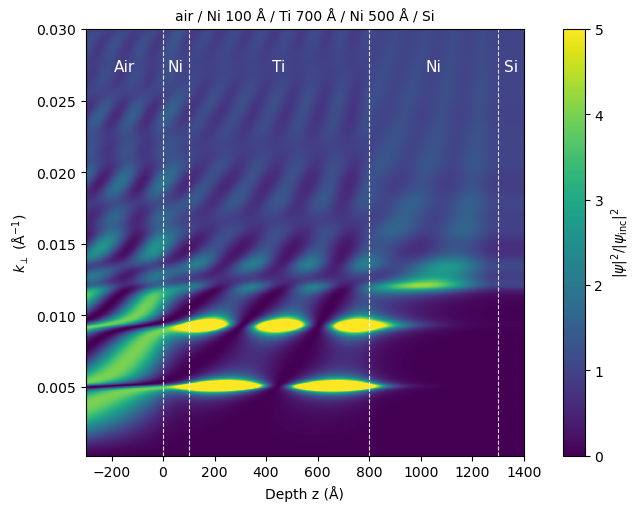

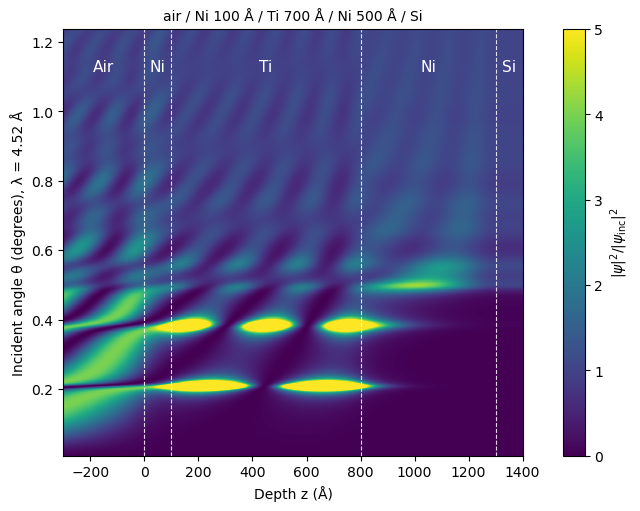

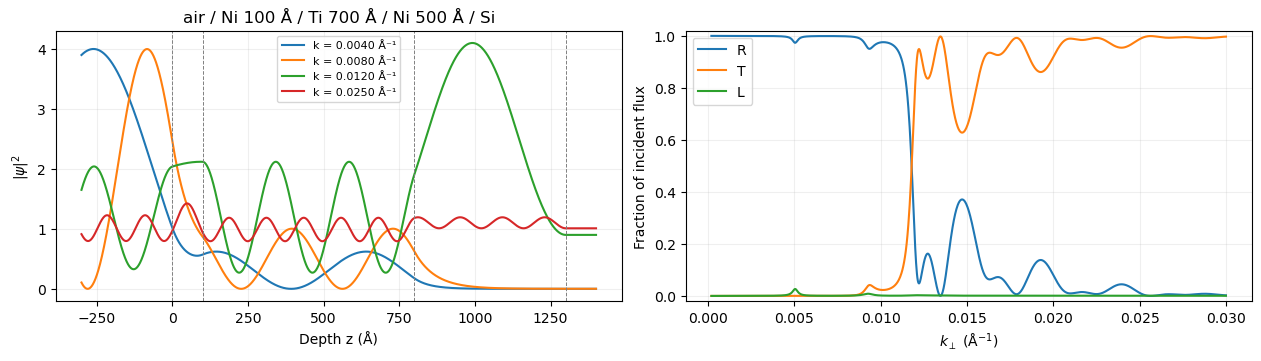

In [61]:
results = main()

## Что возвращается и сохраняется

`results[0]`, `results[1]`, … соответствуют порядку в `STRUCTURES`.

- `psi2`: поле $|\psi|^2$, форма `(n_k, n_z)`;
- `z`: координата в Å, ноль на первой границе, отрицательные значения в падающей среде;
- `k_perp`: нормальная компонента волнового вектора падающей среды в Å$^{-1}$;
- `layers`: массив `[толщина, real SLD, absorption SLD]`;
- `names`, `bounds`: материалы и координаты границ;
- `A_left`, `B_right`, `k`: амплитуды и волновые числа;
- `R`, `T`, `L`: отражение, поток на входе в подложку и поглощение конечных слоёв.

Результаты сохраняются в папку `OUTPUT_DIR`:
`structure_01.npz`, `structure_02.npz`, … и три PNG с картами, срезами и потоками.
Каждый NPZ содержит названия материалов, толщины, SLD и заголовок структуры.
Повторный запуск перезаписывает файлы с теми же номерами. Если уменьшить число структур,
старые NPZ с большими номерами остаются; текущий набор соответствует списку `results`.

## Расчёт и проверки

Физическое ядро сохранено из предыдущей версии: амплитуда падающей волны равна 1,
$\rho=\rho'-i\rho''$, прямая волна $e^{ikz}$.
`B_right` задана на правой границе слоя: $\psi=A e^{ik(z-z_L)}+B e^{ik(z_R-z)}$.
Проверки непрерывности поля, производной и баланса $R+T+L=1$ выполняются всегда.
Дополнительная независимая СЛАУ включается через `CHECK_WITH_DIRECT_SOLVER=True`.
Она предназначена для небольших структур и автоматически пропускается для более 12 сред
или максимального $\mathrm{Im}(k_j)d_j>20$; основной устойчивый расчёт продолжается.
В проверках больше нет обязательной первой структуры Ni/Si.

Включено поглощение захватом; границы резкие, магнитная SLD и шероховатость не учитываются.
При отключённом поглощении избегайте точного $k_j=0$, где базис двух экспонент вырожден.
`q` в ядре означает $k_\perp$, не $Q$: $Q=2k_\perp$.
Угловая карта использует $\theta=\arcsin(k_\perp\lambda/2\pi)$ в падающей среде.
Параметр `WAVELENGTH_A` задаёт длину волны для этого преобразования.
Для больших многослоек увеличивайте `DZ_A`/уменьшайте `N_K` при необходимости:
размер сохранённого поля пропорционален произведению числа точек по обеим осям.

SLD зафиксированы из локального расчёта `periodictable 2.1.0` с объёмными плотностями
(эта версия указана в калькуляторе NIST); веб-форма в предыдущей сессии не выдала результат.

## Источники и документация

- [NIST calculator](https://www.ncnr.nist.gov/resources/activation/)
- [periodictable: neutron_sld и единицы](https://periodictable.readthedocs.io/en/latest/api/nsf.html)
- [PyTorch: torch.sqrt](https://docs.pytorch.org/docs/2.14/generated/torch.sqrt.html)
- [NumPy: numpy.linalg.solve](https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html)
- [Matplotlib: pcolormesh](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.pcolormesh.html)
- [Python: pathlib](https://docs.python.org/3/library/pathlib.html)
- [Обзор с исходными примерами структур, рис. 4 и 6](https://doi.org/10.1039/D5JA00237K)
